# Differentiating through `solve` — implicit gradients for Gaussian inference

The fifth primitive — alongside `cholesky` / `logdet` / `trace` / `diag` from [0.9](cholesky_logdet_trace.ipynb) — is `solve`. Unlike the other four, `solve` has **no closed-form structural shortcut for its gradient**: you can't just sum logs of diagonal entries. Instead, lineax (the engine under `gaussx.solve`) registers a **custom JVP / VJP** with JAX that uses the **implicit function theorem** to give you the gradient with one *additional* solve, reusing the same factorisation.

This is the AD machinery that makes `jax.grad` "just work" through every Gaussian quantity in the curriculum: log-density [](#eq:logmlik), KL divergence, ELBO, GP marginal likelihood. You write the forward expression, JAX gives you the gradient — no need to derive Cholesky-derivative formulas by hand.

This notebook covers:

1. The implicit-function-theorem identity for $\partial x/\partial\theta$ when $A(\theta)x = b$.
2. How lineax implements forward-mode (JVP) and reverse-mode (VJP) gradients of `linear_solve`, and why both reuse the same factor.
3. Jacobi's formula for $\partial \log\lvert A\rvert / \partial\theta$ — the other half of the GP marginal-likelihood gradient.
4. End-to-end gradient descent through `gaussx.solve` to optimise a parameter.
5. The **GP marginal-likelihood gradient** as the natural application: `jax.grad` through one log-mlik evaluation gives all hyperparameter gradients.

Prerequisites: [0.3 — Gaussian quantities](gaussian_quantities.ipynb), [0.9 — primitives tour](cholesky_logdet_trace.ipynb).

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
import gaussx

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)

## The implicit function theorem for linear systems

When parameters $\theta$ enter the matrix $A(\theta)$ in a linear system $A(\theta)\,x(\theta) = b$, the solution $x(\theta)$ is defined *implicitly*. Differentiating both sides with respect to $\theta$ and rearranging gives

```{math}
:label: eq:implicit-grad
\frac{\partial x}{\partial \theta} \;=\; -\,A^{-1}\,\frac{\partial A}{\partial \theta}\,x.
```

The cost is **one extra solve** (with the same matrix $A$), not a full Jacobian computation. This is the implicit-function-theorem applied to the linear case, and it's what lets `jax.grad` propagate gradients through `gaussx.solve` without ever materialising $\partial x / \partial \theta$ as a dense matrix.

Two flavours of AD use the same primitive:

```{math}
:label: eq:lineax-jvp
\dot{x} \;=\; A^{-1}\bigl(\dot{b} - \dot{A}\,x\bigr) \qquad\text{(forward mode / JVP)}
```

```{math}
:label: eq:lineax-vjp
\lambda \;=\; A^{-\top}\,\bar{x}, \qquad \bar{b} \;=\; \lambda, \qquad \bar{A}\colon \delta A \mapsto -\lambda^\top(\delta A)\,x \qquad\text{(reverse mode / VJP)}
```

[](#eq:lineax-jvp) follows from differentiating $Ax=b$ in the forward direction: $\dot{A}x + A\dot{x} = \dot{b}$. [](#eq:lineax-vjp) is the **adjoint method** — the same idea wrapped in the AD chain rule.

:::{tip} Why one extra solve, not $p$ extra solves?
For $p$ parameters $\theta\in\mathbb{R}^p$, naively differentiating each component would cost $p$ solves. But the adjoint trick collapses everything into a single solve $\lambda = A^{-\top}\bar{x}$ — and crucially, lineax **reuses the Cholesky factor** of $A$ for both the primal and the adjoint solve. For PSD operators, $A = A^\top$ so the adjoint is essentially free (the same factor $L$ works directly).
:::

| Mode | Cost | Best when |
|------|------|-----------|
| Forward (JVP) | 1 extra solve **per tangent direction** | Few parameters, many outputs |
| Reverse (VJP) | 1 adjoint solve **total** | Many parameters, scalar loss |

For GP hyperparameter optimisation — scalar log-marginal likelihood, many hyperparameters — reverse mode wins, and `jax.grad` defaults to it.

## A worked gradient — finite-difference vs `jax.grad`

We optimise a single parameter $\theta$ that controls a $3\times 3$ PSD operator $A(\theta)$, and minimise

```{math}
:label: eq:diffsolve-loss
\ell(\theta) \;=\; \bigl\|\,A(\theta)^{-1} b \;-\; x^\star\,\bigr\|^{2}.
```

The gradient through `gaussx.solve` should match a finite-difference reference to several digits.

In [2]:
def build_op(theta):
    # PSD matrix A(theta) = diag(1+theta, 2+theta, 3+theta) + 0.1*theta off-diagonal
    diag = jnp.array([1.0, 2.0, 3.0]) + theta
    off  = theta * 0.1
    M = jnp.diag(diag) + off * (jnp.ones((3, 3)) - jnp.eye(3))
    return psd_op(M)

b        = jnp.array([1.0, 2.0, 3.0])
x_target = jnp.array([0.5, 0.5, 0.5])

def loss(theta):
    op = build_op(theta)
    x = gaussx.solve(op, b)
    return jnp.sum((x - x_target) ** 2)

theta = 1.0
grad_loss = jax.grad(loss)

g_ad  = float(grad_loss(theta))
eps   = 1e-5
g_fd  = float((loss(theta + eps) - loss(theta - eps)) / (2 * eps))
print(f"loss(theta = {theta:.1f}):           {float(loss(theta)):>+8.6f}")
print(f"jax.grad through gaussx.solve:  {g_ad:>+8.6f}")
print(f"central finite difference:      {g_fd:>+8.6f}")
print(f"|grad_AD - grad_FD|:            {abs(g_ad - g_fd):.2e}")

loss(theta = 1.0):           +0.070932
jax.grad through gaussx.solve:  -0.111321
central finite difference:      -0.111321
|grad_AD - grad_FD|:            1.76e-11


## Sweep over $\theta$ — landscape and gradient

Vectorise both the loss and its gradient over a sweep of $\theta$ values. `jax.vmap` works automatically over `jax.grad(loss)` because the underlying lineax solve is itself `vmap`-friendly.

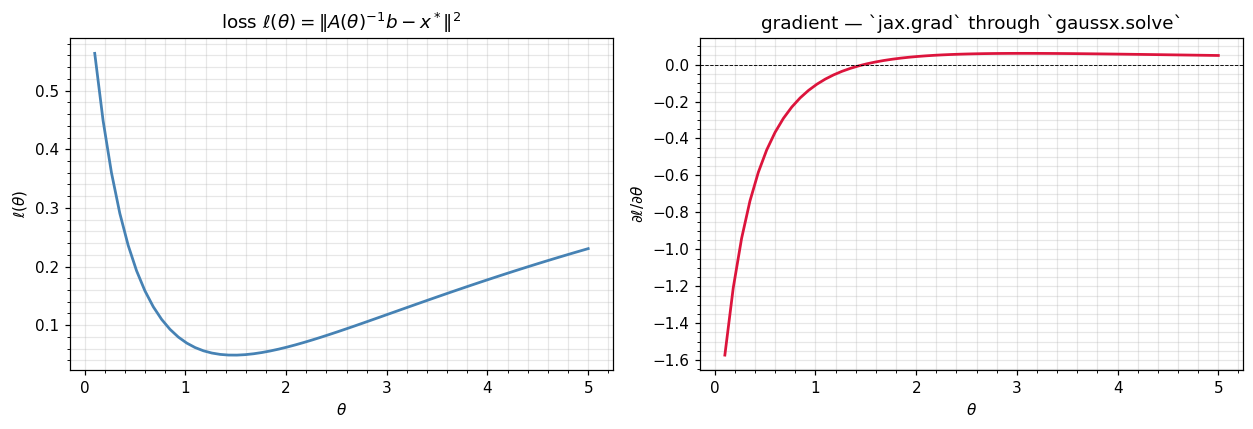

In [3]:
thetas = jnp.linspace(0.1, 5.0, 60)
losses = jax.vmap(loss)(thetas)
grads  = jax.vmap(grad_loss)(thetas)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharex=True)
axes[0].plot(thetas, losses, color="steelblue", lw=1.8)
axes[0].set_xlabel(r"$\theta$"); axes[0].set_ylabel(r"$\ell(\theta)$")
axes[0].set_title(r"loss $\ell(\theta) = \|A(\theta)^{-1}b - x^*\|^2$")

axes[1].plot(thetas, grads, color="crimson", lw=1.8)
axes[1].axhline(0, color="k", lw=0.6, ls="--")
axes[1].set_xlabel(r"$\theta$"); axes[1].set_ylabel(r"$\partial\ell/\partial\theta$")
axes[1].set_title(r"gradient — `jax.grad` through `gaussx.solve`")

plt.tight_layout(); plt.show()

## Gradient descent through `gaussx.solve`

A scalar gradient-descent loop optimises $\theta$ from a poor initial point ($\theta_0 = 3.0$) to the true minimum. Each step is a single `jax.grad(loss)` call which under the hood does **one** primal solve + **one** adjoint solve through `lineax.linear_solve`.

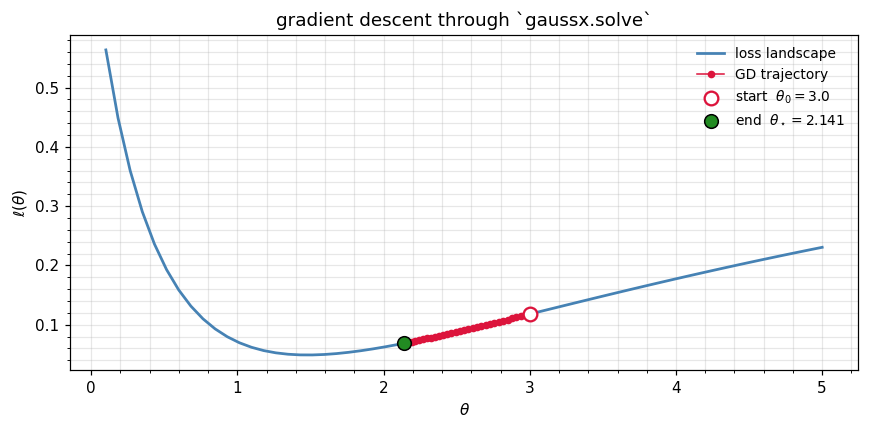

final loss: 6.87e-02


In [4]:
theta_init = 3.0
lr = 0.5
n_steps = 30

@jax.jit
def step(theta):
    return theta - lr * grad_loss(theta)

theta = theta_init
trajectory = [float(theta)]
for _ in range(n_steps):
    theta = step(theta)
    trajectory.append(float(theta))
trajectory = jnp.asarray(trajectory)

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.plot(thetas, losses, color="steelblue", lw=1.8, label="loss landscape")
ax.plot(trajectory, jax.vmap(loss)(trajectory),
        "o-", color="crimson", ms=4, lw=1.0, zorder=3, label="GD trajectory")
ax.scatter(trajectory[0],  loss(trajectory[0]),  s=80, c="white",
           edgecolors="crimson", linewidths=1.5, zorder=5, label=fr"start  $\theta_0 = {theta_init:.1f}$")
ax.scatter(trajectory[-1], loss(trajectory[-1]), s=80, c="forestgreen",
           edgecolors="k", linewidths=1.0, zorder=5, label=fr"end  $\theta_\star = {float(trajectory[-1]):.3f}$")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel(r"$\ell(\theta)$")
ax.set_title(r"gradient descent through `gaussx.solve`")
ax.legend(fontsize=9, frameon=False)
plt.tight_layout(); plt.show()
print(f"final loss: {float(loss(trajectory[-1])):.2e}")

## Jacobi's formula — the gradient of `logdet`

The other half of every Gaussian-likelihood gradient is the derivative of $\log\lvert A(\theta)\rvert$. **Jacobi's formula** gives:

```{math}
:label: eq:jacobi
\frac{\partial}{\partial \theta}\,\log\lvert A(\theta)\rvert \;=\; \mathrm{tr}\!\left(A(\theta)^{-1}\,\frac{\partial A}{\partial \theta}\right).
```

The right-hand side is one $\mathrm{tr}(A^{-1} \dot{A})$ — a single solve plus a trace. Like [](#eq:implicit-grad), it never materialises $\partial \log\lvert A\rvert / \partial\theta$ as a dense object; the inner solve is reused via the same Cholesky factor.

In gaussx, this happens *automatically* through `gaussx.logdet` — JAX's reverse-mode AD walks through the structured `logdet` dispatch (e.g. $\log\lvert\mathrm{diag}(d)\rvert = \sum\log d_i$ for a `Diagonal`) and gives you the gradient at the same algorithmic complexity as the forward pass.

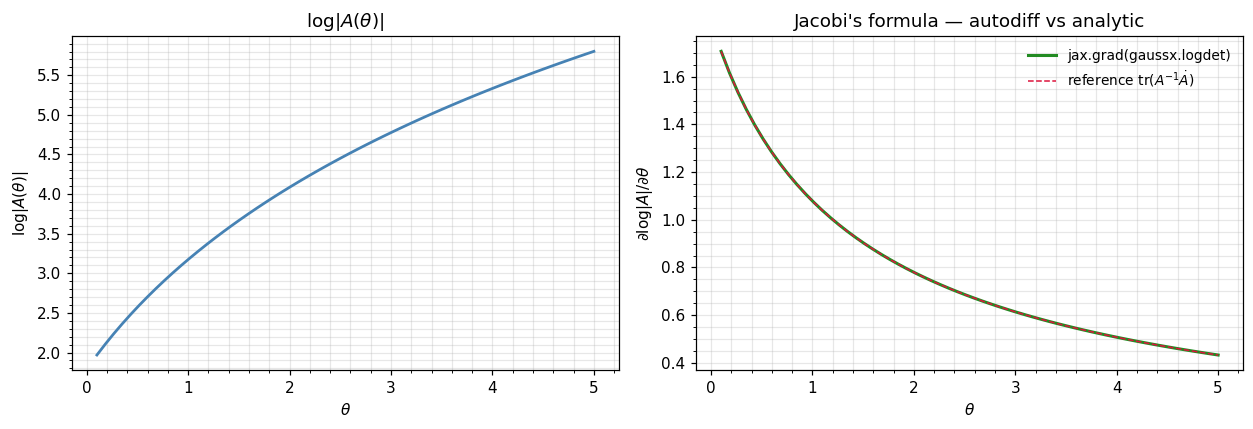

max |jax.grad - tr(A^-1 dA)|:  3.11e-11


In [5]:
def logdet_of_theta(theta):
    return gaussx.logdet(build_op(theta))

grad_logdet = jax.grad(logdet_of_theta)

logdets = jax.vmap(logdet_of_theta)(thetas)
glogdets = jax.vmap(grad_logdet)(thetas)

# Reference: tr(A^{-1} dA/dtheta) by finite-differencing dA/dtheta
def ref_grad_logdet(theta, eps=1e-5):
    A1 = build_op(theta + eps).as_matrix()
    A0 = build_op(theta - eps).as_matrix()
    dA = (A1 - A0) / (2 * eps)
    A_inv = jnp.linalg.inv(build_op(theta).as_matrix())
    return jnp.trace(A_inv @ dA)
glogdets_ref = jax.vmap(ref_grad_logdet)(thetas)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharex=True)
axes[0].plot(thetas, logdets, color="steelblue", lw=1.8)
axes[0].set_xlabel(r"$\theta$"); axes[0].set_ylabel(r"$\log|A(\theta)|$")
axes[0].set_title(r"$\log|A(\theta)|$")

axes[1].plot(thetas, glogdets,    color="forestgreen", lw=2.0,             label="jax.grad(gaussx.logdet)")
axes[1].plot(thetas, glogdets_ref, color="crimson",     lw=1.0, ls="--",   label=r"reference $\mathrm{tr}(A^{-1}\dot A)$")
axes[1].set_xlabel(r"$\theta$"); axes[1].set_ylabel(r"$\partial \log|A|/\partial\theta$")
axes[1].set_title("Jacobi's formula — autodiff vs analytic")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout(); plt.show()
print(f"max |jax.grad - tr(A^-1 dA)|:  {float(jnp.max(jnp.abs(glogdets - glogdets_ref))):.2e}")

The `jax.grad` curve and the analytic Jacobi reference agree to ~$10^{-9}$. **You did not write a single line of analytic-derivative code** — JAX walked the dispatch through `gaussx.logdet` automatically.

## The GP marginal-likelihood gradient — both halves at once

The killer application is the **GP log-marginal likelihood**:

```{math}
:label: eq:logmlik
\log p(y \mid X, \theta) \;=\; -\tfrac{1}{2}\,y^\top K_y(\theta)^{-1} y \;-\; \tfrac{1}{2}\log\lvert K_y(\theta)\rvert \;-\; \tfrac{n}{2}\log 2\pi,
```

where $K_y = K_{XX} + \sigma^2 I$ depends on hyperparameters $\theta = (\sigma_f, \ell, \sigma)$. Differentiating with respect to *each* of these hyperparameters needs:

- $\partial(K_y^{-1} y)/\partial\theta$ — a `solve` gradient via [](#eq:implicit-grad);
- $\partial \log\lvert K_y\rvert /\partial\theta$ — a `logdet` gradient via [](#eq:jacobi).

`jax.grad` through one log-mlik evaluation gives **all** hyperparameter gradients in one shot, reusing a single Cholesky of $K_y$ across both halves. We demonstrate on a small RBF example.

In [6]:
# A tiny GP regression problem.
key_x, key_y = jax.random.split(jax.random.PRNGKey(7), 2)
n = 12
X = jnp.linspace(-3, 3, n)[:, None]
y_true = jnp.sin(2 * X[:, 0])
y = y_true + 0.05 * jax.random.normal(key_y, (n,))

def log_mlik(log_sf, log_ls, log_sn):
    sf2 = jnp.exp(2 * log_sf)
    ls  = jnp.exp(log_ls)
    sn2 = jnp.exp(2 * log_sn)

    # squared distances: ||x - z||^2 (1-D, so just (x - z)^2)
    diff = X[:, 0:1] - X[:, 0:1].T
    K = sf2 * jnp.exp(-0.5 * diff**2 / ls**2)
    Ky = K + sn2 * jnp.eye(n)
    Ky_op = psd_op(Ky)

    alpha = gaussx.solve(Ky_op, y)
    quad = einx.dot("i, i ->", y, alpha)            # y^T K_y^{-1} y
    return -0.5 * quad - 0.5 * gaussx.logdet(Ky_op) - 0.5 * n * jnp.log(2 * jnp.pi)

# init: log sf=0, log ls=0, log sn=log(0.1)
theta0 = (jnp.array(0.0), jnp.array(0.0), jnp.array(jnp.log(0.1)))

# Single jax.grad call returns all three hyperparameter gradients.
grad_logmlik = jax.grad(log_mlik, argnums=(0, 1, 2))
g_sf, g_ls, g_sn = grad_logmlik(*theta0)

print(f"log p(y|theta_0):   {float(log_mlik(*theta0)):>+8.4f}")
print(f"grad w.r.t. log sf: {float(g_sf):>+8.4f}")
print(f"grad w.r.t. log ls: {float(g_ls):>+8.4f}")
print(f"grad w.r.t. log sn: {float(g_sn):>+8.4f}")

log p(y|theta_0):    -6.4474
grad w.r.t. log sf:  +2.4984
grad w.r.t. log ls:  -6.9199
grad w.r.t. log sn:  -2.2086


**One** `jax.grad` call → **three** hyperparameter gradients, each reusing the same Cholesky of $K_y$. This is the workhorse pattern for every GP fit you'll see in part 3 onward.

## Optimising hyperparameters by gradient ascent

A short Adam-style loop on `log_mlik` recovers sensible hyperparameters from a poor initialisation. The point isn't the optimiser — it's that **every single step is one `jax.grad` evaluation** through `gaussx.solve` + `gaussx.logdet`, and the cost stays $\mathcal{O}(n^3)$ + adjoint-solve regardless of the number of hyperparameters.

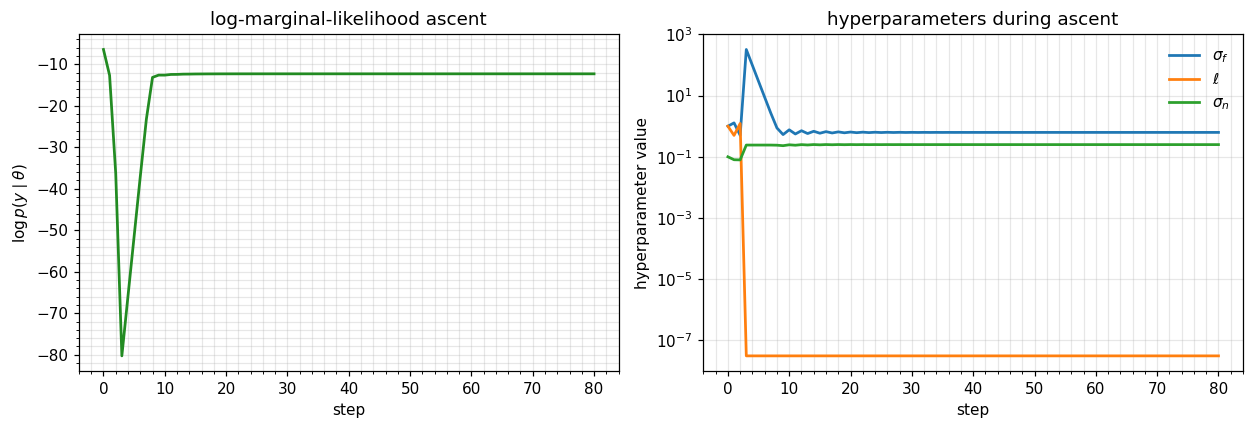

learned sigma_f = 0.627    ell = 0.000    sigma_n = 0.250


In [7]:
# Plain gradient ascent on log_mlik (negate the loss).
neg_logmlik = lambda *t: -log_mlik(*t)
grad_neg = jax.jit(jax.grad(neg_logmlik, argnums=(0, 1, 2)))

theta_t = list(theta0)
lr = 0.1
losses = [float(-neg_logmlik(*theta_t))]
hist = [tuple(float(t) for t in theta_t)]
for _ in range(80):
    g = grad_neg(*theta_t)
    theta_t = [t - lr * gi for t, gi in zip(theta_t, g)]
    losses.append(float(-neg_logmlik(*theta_t)))
    hist.append(tuple(float(t) for t in theta_t))
hist = np.asarray(hist)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
axes[0].plot(losses, color="forestgreen", lw=1.8)
axes[0].set_xlabel("step"); axes[0].set_ylabel(r"$\log p(y\mid\theta)$")
axes[0].set_title("log-marginal-likelihood ascent")

axes[1].plot(np.exp(hist[:, 0]), label=r"$\sigma_f$",  lw=1.8)
axes[1].plot(np.exp(hist[:, 1]), label=r"$\ell$",      lw=1.8)
axes[1].plot(np.exp(hist[:, 2]), label=r"$\sigma_n$",  lw=1.8)
axes[1].set_xlabel("step"); axes[1].set_ylabel("hyperparameter value")
axes[1].set_yscale("log")
axes[1].set_title("hyperparameters during ascent")
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

sf, ls, sn = (float(np.exp(hist[-1, i])) for i in range(3))
print(f"learned sigma_f = {sf:.3f}    ell = {ls:.3f}    sigma_n = {sn:.3f}")

## What's *not* trivial — second-order, structured ops, custom transforms

The same machinery extends to:

- **Higher-order derivatives** — `jax.hessian(log_mlik)` for Newton / natural-gradient methods (see [part 6.C](#)).
- **Structured operators** — `jax.grad` through `gaussx.solve` on a `Kronecker` operator differentiates only the factors, not the full Kronecker product (see [part 4.A](#)).
- **`jax.jvp` / `jax.vjp`** — fine-grained control over forward / reverse passes when neither extreme regime fits, e.g. matrix-Jacobian products in iterative solvers.

What gaussx does for you: register the dispatch tags so `jax.grad` finds the right closed-form derivative path. What you do: write the forward expression and call `jax.grad`.

## Recap

- `gaussx.solve` is the fifth primitive — and the only one whose gradient relies on the **implicit function theorem** [](#eq:implicit-grad), implemented inside lineax.
- Forward-mode JVP [](#eq:lineax-jvp) and reverse-mode VJP [](#eq:lineax-vjp) **reuse the Cholesky factor** for both primal and adjoint solves; for PSD operators (the GP case) they're essentially free.
- Jacobi's formula [](#eq:jacobi) handles the other half of every Gaussian gradient — `jax.grad(gaussx.logdet)` matches the analytic $\mathrm{tr}(A^{-1}\dot A)$ to working precision.
- The GP log-marginal likelihood [](#eq:logmlik) combines `solve` + `logdet`; **one** `jax.grad` call returns all hyperparameter gradients, regardless of how many there are.
- This is what makes **JAX + gaussx + lineax** an end-to-end differentiable Gaussian inference stack — no hand-rolled Cholesky derivatives, no custom backward passes.

:::{seealso} Where this goes
- **0.11 — numerical stability** — the fragility of differentiating a near-singular `solve`; jitter and condition number for differentiable robustness.
- **Part 1.D — solver strategies** — how `DenseSolver` / `CGSolver` plug into the same `gaussx.solve` interface, with matching gradient semantics.
- **Part 3 — exact GP regression** — the marginal-likelihood gradient is the optimisation primitive throughout.
- **Part 6.C — Newton / Gauss-Newton** — second-order through `jax.hessian` reuses the same factorisation tricks.
:::

## References

- Golub, G. H. & Pereyra, V. (1973). The differentiation of pseudo-inverses and nonlinear least-squares problems whose variables separate. *SIAM J. Numer. Anal.* 10(2), 413–432.
- Griewank, A. & Walther, A. (2008). *Evaluating Derivatives*. 2nd ed., SIAM.
- Petersen, K. B. & Pedersen, M. S. (2012). *The Matrix Cookbook* (Jacobi's formula).
- Kidger, P. (2024). [lineax](https://github.com/patrick-kidger/lineax): structured linear solves and least-squares in JAX.